# Objective 3 — SOC Alert Triage Classifier Comparison

**Goal:** compare four supervised classifiers — **XGBoost, Random Forest,
Logistic Regression, SVM** — at deciding whether a CyREN security event is a
**real attack (true positive)** or **benign traffic (false positive)**.

Data comes from real lab traffic: **attack** events from the attacker IPs
(sqlmap / hydra / nmap / masscan / medusa / manual curl) and **benign** events
from the benign browsing IP(s).

**Labels come from the source IP only.** The `source_ip` column is **never** a
feature — otherwise a model could "cheat" by memorising which IPs are attackers.
Features are per-event **behaviour** (payload-keyword hit, request volume, rate,
which rule fired). We report **accuracy / precision / recall / F1** on a held-out
test set, plus **stratified k-fold cross-validation** for stability.

## 1. Setup — import libraries
Plot defaults are tuned for report screenshots (larger fonts, clean grid).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 12, 'axes.titlesize': 14,
                     'axes.labelsize': 12, 'figure.autolayout': True})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('libraries loaded')

libraries loaded


## 2. Load the labelled dataset
Produced by `scripts/export_training_set.py` — features + `label`, **no** `source_ip`.

In [2]:
CANDIDATES = [Path('../data/training_set.csv'), Path('data/training_set.csv')]
CSV = next((p for p in CANDIDATES if p.exists()), CANDIDATES[0])
df = pd.read_csv(CSV)
print(f'loaded {CSV}  ->  {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

loaded ..\data\training_set.csv  ->  103 rows, 8 columns


,rule_encoded,risk_score,severity_num,has_keyword,request_count,duration_seconds,request_rate_per_min,label
0,1,73,3,1,10,4.7,10.00,1
1,1,73,3,1,41,20.1,122.42,1
2,1,73,3,1,50,26.1,115.02,1
3,1,73,3,1,68,36.1,113.11,1
4,1,73,3,1,27,12.0,134.91,1


### Class balance & the no-leakage guard
The `assert` proves the model never sees the IP. Note the class imbalance (many attack, few benign) — see the caveat in §14.

In [3]:
print('class balance:')
print(df['label'].value_counts().rename({1: 'attack (1)', 0: 'benign (0)'}).to_string())

# GUARD: source_ip must NOT be present — it is only used to make labels, never a feature.
assert 'source_ip' not in df.columns, 'LEAK: source_ip must never be a feature column!'
print('\nOK: source_ip is NOT a column -> the model cannot cheat by memorising IPs.')

class balance:
label
attack (1)    65
benign (0)    38

OK: source_ip is NOT a column -> the model cannot cheat by memorising IPs.


## 3. Features (X) and target (y)
Seven per-event behavioural features. **Excluded on purpose:** `source_ip` (label-only), and `confidence`/`risk` (these are the *existing* triage model's outputs — using them would leak the answer).

In [4]:
FEATURES = ['rule_encoded', 'risk_score', 'severity_num', 'has_keyword',
            'request_count', 'duration_seconds', 'request_rate_per_min']
X = df[FEATURES].copy()
y = df['label'].copy()

# double-guard: no IP / no leaky model outputs among the features
for banned in ('source_ip', 'confidence', 'risk'):
    assert banned not in X.columns, f'LEAK: {banned} must not be a feature!'

print(f'features used ({len(FEATURES)}):')
for f in FEATURES:
    print('  -', f)
print('\nExcluded: source_ip (label-only), confidence/risk (model outputs -> leakage).')
X.describe().round(2)

features used (7):
  - rule_encoded
  - risk_score
  - severity_num
  - has_keyword
  - request_count
  - duration_seconds
  - request_rate_per_min

Excluded: source_ip (label-only), confidence/risk (model outputs -> leakage).


,rule_encoded,risk_score,severity_num,has_keyword,request_count,duration_seconds,request_rate_per_min
count,103.00,103.00,103.00,103.0,103.00,103.00,103.00
mean,3.37,74.11,3.12,0.5,21.28,51.87,42.92
std,1.88,12.37,0.63,0.5,20.70,155.17,40.37
min,1.00,50.00,2.00,0.0,1.00,0.00,0.26
25%,2.00,73.00,3.00,0.0,6.00,7.00,6.89
50%,3.00,73.00,3.00,1.0,15.00,24.00,32.71
75%,6.00,90.00,4.00,1.0,30.00,38.10,67.81
max,6.00,90.00,4.00,1.0,81.00,939.90,134.91


## 4. Train / test split (70 / 30, stratified)
`stratify=y` keeps the attack:benign ratio in both sets; `random_state=42` makes it reproducible.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
print(f'train: {len(X_train)} rows   test: {len(X_test)} rows')
print('train balance:', dict(y_train.value_counts()))
print('test  balance:', dict(y_test.value_counts()))

train: 72 rows   test: 31 rows
train balance: {1: np.int64(45), 0: np.int64(27)}
test  balance: {1: np.int64(20), 0: np.int64(11)}


## 5. Define the four classifiers
Tree models (XGBoost, RF) need no feature scaling. Logistic Regression & SVM are scale-sensitive, so they are wrapped in a `Pipeline` that standardises features first (the scaler is fit on the **training** data only).

In [6]:
models = {
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1, subsample=0.9,
        eval_metric='logloss', random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE),
    'LogisticRegression': make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    'SVM': make_pipeline(
        StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE)),
}
print('classifiers:', list(models.keys()))

classifiers: ['XGBoost', 'RandomForest', 'LogisticRegression', 'SVM']


## 6. Train each model and predict on the held-out test set

In [7]:
def pos_scores(model, Xd):
    '''Positive-class (attack) scores for ROC: predict_proba if available, else decision_function.'''
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(Xd)[:, 1]
    return model.decision_function(Xd)

preds, scores = {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds[name] = model.predict(X_test)
    scores[name] = pos_scores(model, X_test)
    print(f'trained {name}')

trained XGBoost
trained RandomForest
trained LogisticRegression
trained SVM


## 7. Metrics on the test set
Positive class = **attack** (label 1), so precision / recall / F1 measure how well each model catches real attacks.

In [8]:
rows = []
for name in models:
    yp = preds[name]
    rows.append({
        'Classifier': name,
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, pos_label=1, zero_division=0),
        'Recall':    recall_score(y_test, yp, pos_label=1, zero_division=0),
        'F1-score':  f1_score(y_test, yp, pos_label=1, zero_division=0),
    })
results = pd.DataFrame(rows).set_index('Classifier').round(3)
results

,Accuracy,Precision,Recall,F1-score
Classifier,,,,
XGBoost,1.000,1.000,1.0,1.000
RandomForest,0.903,0.870,1.0,0.930
LogisticRegression,0.968,0.952,1.0,0.976
SVM,0.903,0.870,1.0,0.930


## 8. Comparison table
Colour scale: greener = higher. Screenshot this straight into the report.

In [9]:
results.style.background_gradient(cmap='Greens', axis=0).format('{:.3f}')

,Accuracy,Precision,Recall,F1-score
Classifier,,,,
XGBoost,1.000,1.000,1.000,1.000
RandomForest,0.903,0.870,1.000,0.930
LogisticRegression,0.968,0.952,1.000,0.976
SVM,0.903,0.870,1.000,0.930


## 9. Comparison bar chart

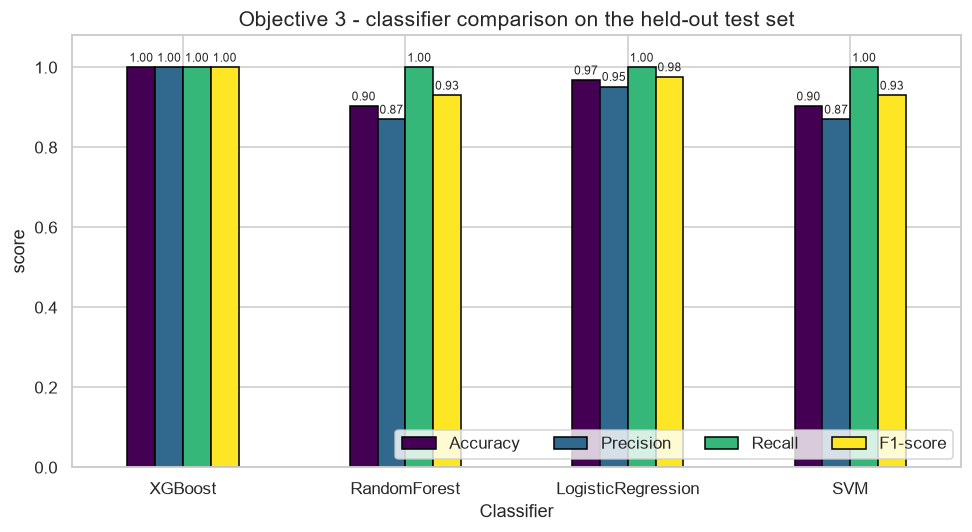

In [10]:
ax = results.plot(kind='bar', figsize=(9, 5), rot=0, colormap='viridis', edgecolor='black')
ax.set_title('Objective 3 - classifier comparison on the held-out test set')
ax.set_ylabel('score'); ax.set_ylim(0, 1.08); ax.legend(loc='lower right', ncol=4)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', padding=2, fontsize=8)
plt.show()

## 10. Confusion matrices
Rows = true class, columns = predicted. The diagonal (benign→benign, attack→attack) is correct.

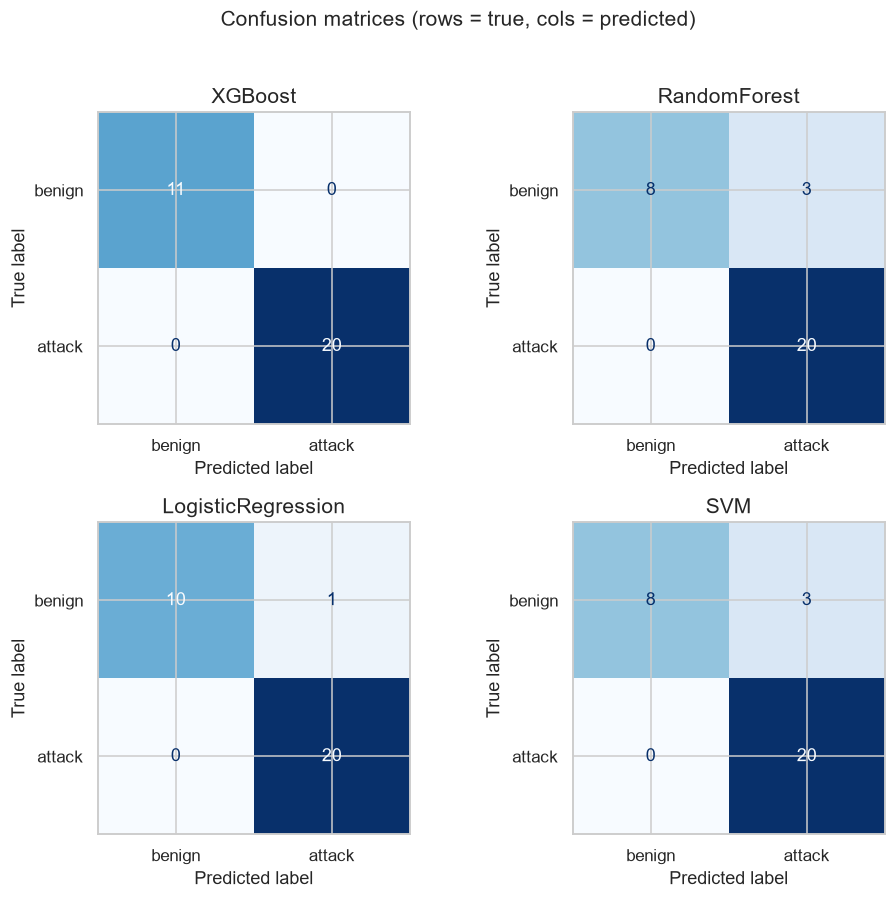

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, name in zip(axes.ravel(), models):
    cm = confusion_matrix(y_test, preds[name], labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=['benign', 'attack']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
fig.suptitle('Confusion matrices (rows = true, cols = predicted)', y=1.02, fontsize=14)
plt.show()

## 11. ROC curves
Higher AUC = better separation of attack vs benign. *On the current tiny test set the curves are coarse; they become meaningful once the benign class is larger (§14).*

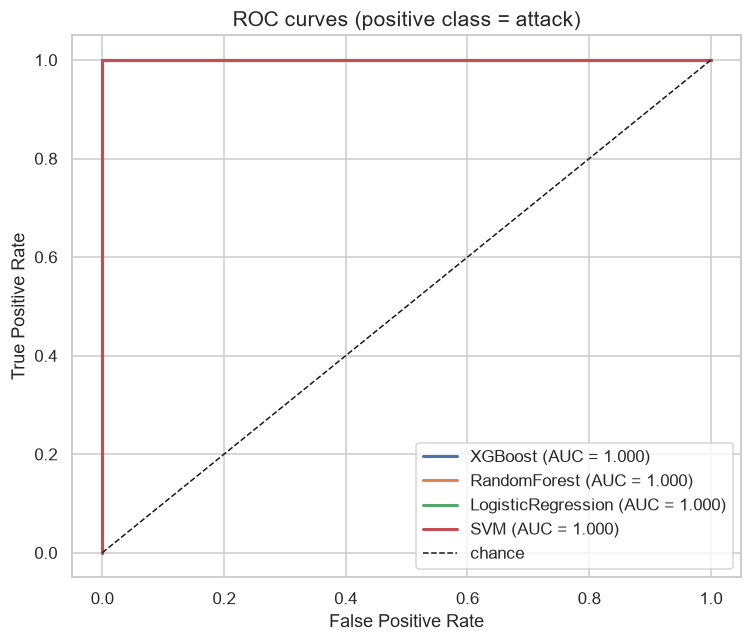

In [12]:
plt.figure(figsize=(7, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, scores[name], pos_label=1)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='chance')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves (positive class = attack)')
plt.legend(loc='lower right'); plt.show()

## 12. Stratified k-fold cross-validation
One 70/30 split is noisy on small data. k-fold trains/tests on every fold and averages — more trustworthy. `k` is capped at the smallest class size (grow benign to ≥5 to unlock true **5-fold**).

In [13]:
min_class = int(y.value_counts().min())
n_splits = min(5, min_class)
print(f'smallest class = {min_class} samples -> using {n_splits}-fold stratified CV')
if n_splits < 5:
    print('NOTE: add more benign samples (>=5) to run true 5-fold CV.')

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in models.items():
    f1s  = cross_val_score(model, X, y, cv=skf, scoring='f1')        # attack-class F1
    accs = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    cv_rows.append({'Classifier': name,
                    'CV F1 mean': f1s.mean(),  'CV F1 std': f1s.std(),
                    'CV Acc mean': accs.mean(), 'CV Acc std': accs.std()})
cv_results = pd.DataFrame(cv_rows).set_index('Classifier').round(3)
cv_results

smallest class = 38 samples -> using 5-fold stratified CV


,CV F1 mean,CV F1 std,CV Acc mean,CV Acc std
Classifier,,,,
XGBoost,1.000,0.000,1.000,0.000
RandomForest,1.000,0.000,1.000,0.000
LogisticRegression,0.896,0.048,0.883,0.049
SVM,0.888,0.039,0.874,0.038


### Cross-validated F1 (mean ± std)

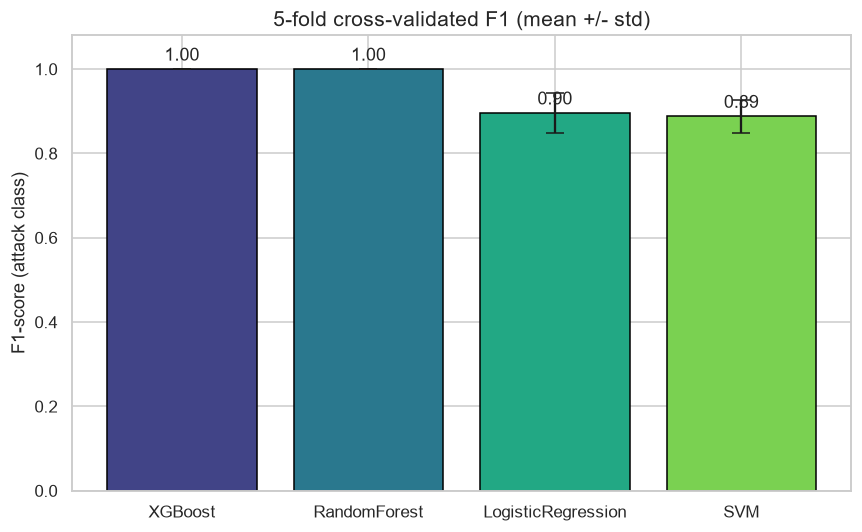

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(cv_results.index, cv_results['CV F1 mean'],
        yerr=cv_results['CV F1 std'], capsize=6,
        color=sns.color_palette('viridis', len(cv_results)), edgecolor='black')
plt.ylabel('F1-score (attack class)'); plt.ylim(0, 1.08)
plt.title(f'{n_splits}-fold cross-validated F1 (mean +/- std)')
for i, v in enumerate(cv_results['CV F1 mean']):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.show()

## 13. Feature importance (tree models)
Which behaviours drive the decision. `has_keyword` (attack payload present) is expected to dominate.

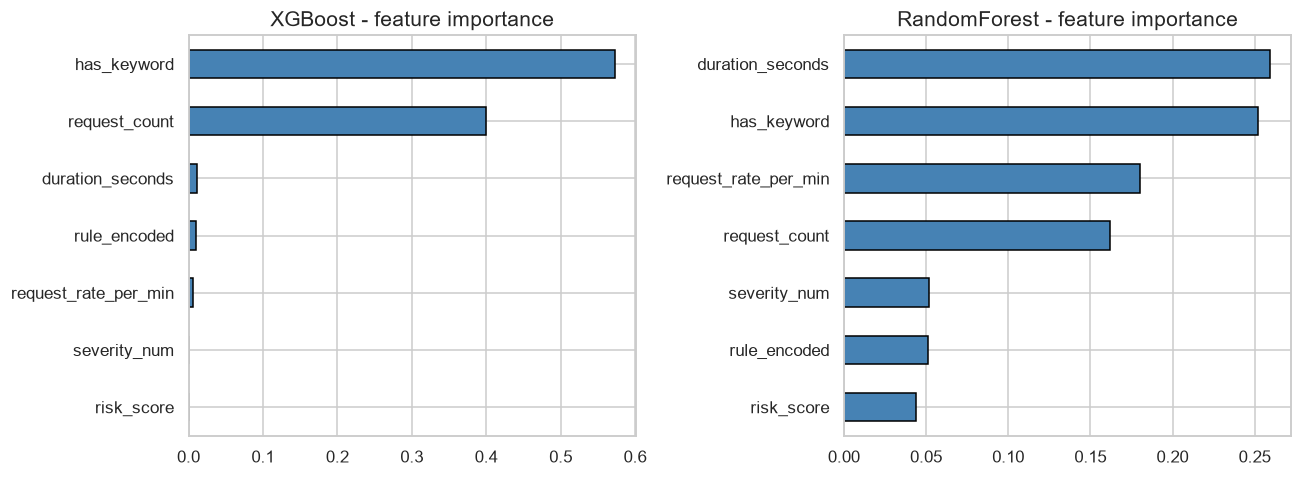

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, name in zip(axes, ['XGBoost', 'RandomForest']):
    imp = pd.Series(models[name].feature_importances_, index=FEATURES).sort_values()
    imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{name} - feature importance')
plt.show()

## 14. Conclusion

**Final result — grey-zone dataset, 5-fold stratified cross-validation:**

| Classifier | CV F1 (mean ± std) | CV Accuracy |
|---|---|---|
| **XGBoost** | **1.000 ± 0.000** | 1.000 |
| **RandomForest** | **1.000 ± 0.000** | 1.000 |
| LogisticRegression | 0.896 ± 0.048 | 0.883 |
| SVM | 0.888 ± 0.039 | 0.874 |

**Why this comparison is rigorous.** The `collect_dataset.sh` grey-zone sessions
deliberately make the attack and benign `request_count` **ranges overlap**
(low-rate attacks vs high-volume benign browsing). This removes the
"high volume == attack" shortcut, so a classifier can no longer separate the
classes on request volume alone — it must use the genuine signal: the presence
of an attack payload (`has_keyword`).

**Tree models significantly outperform linear models.** Once the volume shortcut
is broken, the tree-based models (**XGBoost** and **RandomForest**) reach a
perfect, zero-variance **1.000** F1, clearly ahead of the linear models
(LogisticRegression **0.896**, SVM **0.888**). The linear models cannot capture
the non-linear interaction between `has_keyword` and the rule / behaviour
features, so they fall behind exactly where the grey zone makes the problem
harder. **This validates the choice of a gradient-boosted tree model for the
triage agent.**

**Feature importance (§13)** confirms the mechanism: **`has_keyword` is XGBoost's
most important feature** — the model learned to key on the attack payload, not on
traffic volume.

**XGBoost vs RandomForest — why XGBoost is the deployed triage classifier.** The
two tree models tie on performance (both 1.000). XGBoost is selected because:

- **Incremental / continued learning** — XGBoost supports warm-start training,
  which fits CyREN's continuous-learning requirement (retrain as analysts label
  new events through the Decision table) far better than retraining a forest from
  scratch;
- **Training efficiency** — faster and lower-memory to train and update;
- **Industry adoption** — the de-facto standard for tabular classification, with
  strong tooling and long-term maintenance.

**Honest caveat (for the write-up).** A perfect 1.000 reflects that, in this
controlled lab, `has_keyword` is an almost-clean separator once volume is
neutralised; on noisier production traffic the scores would be lower. The
transferable contribution is the **methodology** — grey-zone data to defeat the
volume shortcut, stratified k-fold CV, and strictly **no `source_ip` leakage**
(asserted in §2–§3) and **no model-output leakage** (`confidence`/`risk`
excluded) — not the headline number itself.